# O-4 / TEM Traffic Pattern Analysis

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from scipy.stats import f_oneway, kruskal, chi2_contingency, ttest_ind
from sklearn.cluster import DBSCAN
from shapely.geometry import LineString, Point
from pyproj import Transformer

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

LAT_MIN, LAT_MAX = 40.935, 41.005
LON_MIN, LON_MAX = 29.105, 29.335
CENTERLINE_SPEED_THRESHOLD = 80
NIGHT_START_HOUR, NIGHT_END_HOUR = 20, 6
ROUTE_BUFFER_M = 50
SLOW_THRESHOLD = 45
EPS_METERS = 120
MIN_SAMPLES = 40
EARTH_RADIUS_M = 6_371_000
WINDOW_ORDER = ["Morning Peak", "Midday", "Evening Peak"]
DIRECTION_ORDER = ["Eastbound", "Westbound", "Undetermined"]

def get_database_url():
    url = os.environ.get("TESLAMATE_DATABASE_URL")
    if url:
        return url
    db_name = os.environ.get("TESLAMATE_DB_NAME", "teslamate_may")
    return f"postgresql://localhost/{db_name}"

def load_positions():
    engine = create_engine(get_database_url())
    with engine.connect() as conn:
        raw_rows = int(conn.execute(text("SELECT COUNT(*) FROM positions")).scalar())
    query = """
        SELECT date, latitude, longitude, speed
        FROM positions
        WHERE latitude IS NOT NULL
          AND longitude IS NOT NULL
          AND speed IS NOT NULL
    """
    df = pd.read_sql(query, engine)
    return raw_rows, df

def add_time_fields(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df["speed"] = pd.to_numeric(df["speed"], errors="coerce")
    df = df.dropna(subset=["date", "latitude", "longitude", "speed"]).copy()
    df["hour"] = df["date"].dt.hour
    df["minute"] = df["date"].dt.minute
    return df

def assign_window_from_time(hour, minute):
    minutes = hour * 60 + minute
    if 6 * 60 <= minutes < 10 * 60 + 30:
        return "Morning Peak"
    if 10 * 60 + 30 <= minutes < 14 * 60 + 30:
        return "Midday"
    if 15 * 60 <= minutes < 20 * 60:
        return "Evening Peak"
    return None

def dominant_value(values):
    counts = values.value_counts()
    return counts.index[0] if len(counts) else np.nan

def p_label(p):
    return "< 0.001" if p < 0.001 else f"{p:.4f}"

def run_pipeline():
    raw_rows, df_loaded = load_positions()
    rows_loaded = len(df_loaded)

    df = add_time_fields(df_loaded)
    rows_parsed = len(df)

    df = df[(df["speed"] >= 0) & (df["speed"] <= 200)].copy()
    rows_speed_valid = len(df)

    df = df.drop_duplicates(subset=["date", "latitude", "longitude", "speed"]).copy()
    rows_deduped = len(df)

    df_candidate = df[
        (df["latitude"] >= LAT_MIN) & (df["latitude"] <= LAT_MAX) &
        (df["longitude"] >= LON_MIN) & (df["longitude"] <= LON_MAX)
    ].copy()
    rows_candidate = len(df_candidate)

    night_high_speed = df_candidate[
        ((df_candidate["hour"] >= NIGHT_START_HOUR) | (df_candidate["hour"] < NIGHT_END_HOUR)) &
        (df_candidate["speed"] > CENTERLINE_SPEED_THRESHOLD)
    ].copy()
    rows_night_high_speed = len(night_high_speed)

    to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32635", always_xy=True)
    x, y = to_utm.transform(night_high_speed["longitude"].to_numpy(), night_high_speed["latitude"].to_numpy())
    night_high_speed["x"] = x
    night_high_speed["y"] = y

    mainline_clusterer = DBSCAN(eps=250, min_samples=30)
    night_high_speed["mainline_cluster"] = mainline_clusterer.fit_predict(night_high_speed[["x", "y"]].to_numpy())
    valid_clusters = night_high_speed.loc[night_high_speed["mainline_cluster"] != -1, "mainline_cluster"]
    largest_mainline_cluster = valid_clusters.value_counts().idxmax()
    mainline_points = night_high_speed[night_high_speed["mainline_cluster"] == largest_mainline_cluster].copy()

    mainline_points["lon_bin"] = (mainline_points["longitude"] / 0.002).round() * 0.002
    centerline_df = (
        mainline_points.groupby("lon_bin")
        .agg(longitude=("longitude", "median"), latitude=("latitude", "median"), count=("speed", "count"))
        .reset_index()
    )
    centerline_df = centerline_df[centerline_df["count"] >= 10].sort_values("longitude").reset_index(drop=True)

    route_xy = [to_utm.transform(lon, lat) for lon, lat in zip(centerline_df["longitude"], centerline_df["latitude"])]
    route_line = LineString(route_xy)

    x_all, y_all = to_utm.transform(df_candidate["longitude"].to_numpy(), df_candidate["latitude"].to_numpy())
    points_all = [Point(px, py) for px, py in zip(x_all, y_all)]
    df_candidate["distance_to_centerline_m"] = [route_line.distance(point) for point in points_all]
    df_candidate["route_position_m"] = [route_line.project(point) for point in points_all]
    df_candidate["route_position_km"] = df_candidate["route_position_m"] / 1000

    df_route = df_candidate[df_candidate["distance_to_centerline_m"] <= ROUTE_BUFFER_M].copy()
    rows_route = len(df_route)

    df_route = df_route.sort_values("date").copy()
    df_route["time_gap_sec"] = df_route["date"].diff().dt.total_seconds()
    df_route["trip_group"] = (df_route["time_gap_sec"] > 600).cumsum()

    trip_positions = df_route.groupby("trip_group").agg(
        start_pos=("route_position_km", "first"),
        end_pos=("route_position_km", "last"),
        point_count=("route_position_km", "count"),
    )
    trip_positions["displacement_km"] = trip_positions["end_pos"] - trip_positions["start_pos"]
    trip_positions["direction"] = "Undetermined"
    trip_positions.loc[trip_positions["displacement_km"] > 1.0, "direction"] = "Eastbound"
    trip_positions.loc[trip_positions["displacement_km"] < -1.0, "direction"] = "Westbound"

    df_route = df_route.merge(trip_positions[["direction"]], left_on="trip_group", right_index=True, how="left")
    rows_directed = int((df_route["direction"] != "Undetermined").sum())

    df_time = df_route.copy()
    df_time["time_window"] = [assign_window_from_time(h, m) for h, m in zip(df_time["hour"], df_time["minute"])]
    df_time = df_time[df_time["time_window"].notna()].copy()
    df_time["is_slow"] = df_time["speed"] < SLOW_THRESHOLD
    rows_analysis = len(df_time)
    rows_slow = int(df_time["is_slow"].sum())

    filtering_counts = pd.DataFrame([
        ["Raw rows in positions table", raw_rows, raw_rows / raw_rows],
        ["Rows loaded after non-null SQL filter", rows_loaded, rows_loaded / raw_rows],
        ["Rows after timestamp and numeric parsing", rows_parsed, rows_parsed / raw_rows],
        ["Rows after speed validation (0-200 km/h)", rows_speed_valid, rows_speed_valid / raw_rows],
        ["Rows after duplicate removal", rows_deduped, rows_deduped / raw_rows],
        ["Rows inside broad O-4/TEM candidate bounding box", rows_candidate, rows_candidate / raw_rows],
        ["Night high-speed rows used to estimate route centerline", rows_night_high_speed, rows_night_high_speed / raw_rows],
        ["Rows inside final 50 m mainline buffer", rows_route, rows_route / raw_rows],
        ["Rows with inferred direction other than Undetermined", rows_directed, rows_directed / raw_rows],
        ["Rows in morning/midday/evening analysis windows", rows_analysis, rows_analysis / raw_rows],
        ["Slow rows in analysis windows (speed < 45 km/h)", rows_slow, rows_slow / raw_rows],
    ], columns=["stage", "rows", "retained_vs_raw_positions"])

    return df_time, df_route, centerline_df, filtering_counts

df_time, df_route, centerline_df, filtering_counts = run_pipeline()

row_counts = {
    "route_rows": len(df_route),
    "analysis_rows": len(df_time),
    "slow_points": int(df_time["is_slow"].sum()),
    "centerline_waypoints": len(centerline_df),
}
row_counts

{'route_rows': 193930,
 'analysis_rows': 170684,
 'slow_points': 62376,
 'clusters': 7,
 'noise_points': 9,
 'centerline_waypoints': 112}

## 1. Filtering and Analysis Sample

In [2]:
filtering_counts

,stage,rows,retained_vs_raw_positions
0,Raw rows in positions table,676289,1.000000
1,Rows loaded after non-null SQL filter,676286,0.999996
2,Rows after timestamp and numeric parsing,676286,0.999996
3,Rows after speed validation (0-200 km/h),676286,0.999996
4,Rows after duplicate removal,676026,0.999611
5,Rows inside broad O-4/TEM candidate bounding box,300961,0.445018
6,Night high-speed rows used to estimate route c...,4852,0.007174
7,Rows inside final 50 m mainline buffer,193930,0.286756
8,Rows with inferred direction other than Undete...,193114,0.285550
9,Rows in morning/midday/evening analysis windows,170684,0.252383


The analysis keeps 170,684 O-4/TEM observations in the selected time windows. Out of these, 62,376 observations are below 45 km/h.

## 2. Speed by Time Window

In [3]:
time_window_summary = (
    df_time.groupby("time_window")["speed"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max",
         q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75))
    .reindex(WINDOW_ORDER)
    .reset_index()
)
time_window_summary["iqr"] = time_window_summary["q3"] - time_window_summary["q1"]
slow_counts = df_time.groupby("time_window")["is_slow"].sum().reindex(WINDOW_ORDER).astype(int).values
slow_share = df_time.groupby("time_window")["is_slow"].mean().reindex(WINDOW_ORDER).values
time_window_summary["slow_count"] = slow_counts
time_window_summary["slow_share"] = slow_share
time_window_summary

,time_window,count,mean,median,std,min,max,q1,q3,iqr,slow_count,slow_share
0,Morning Peak,60719,67.156903,77.0,32.389196,0,138,39.0,90.0,51.0,16808,0.276816
1,Midday,57006,55.313493,56.0,30.657040,0,126,27.0,82.0,55.0,22923,0.402116
2,Evening Peak,52959,53.792273,53.0,31.159362,0,126,26.0,82.0,56.0,22645,0.427595


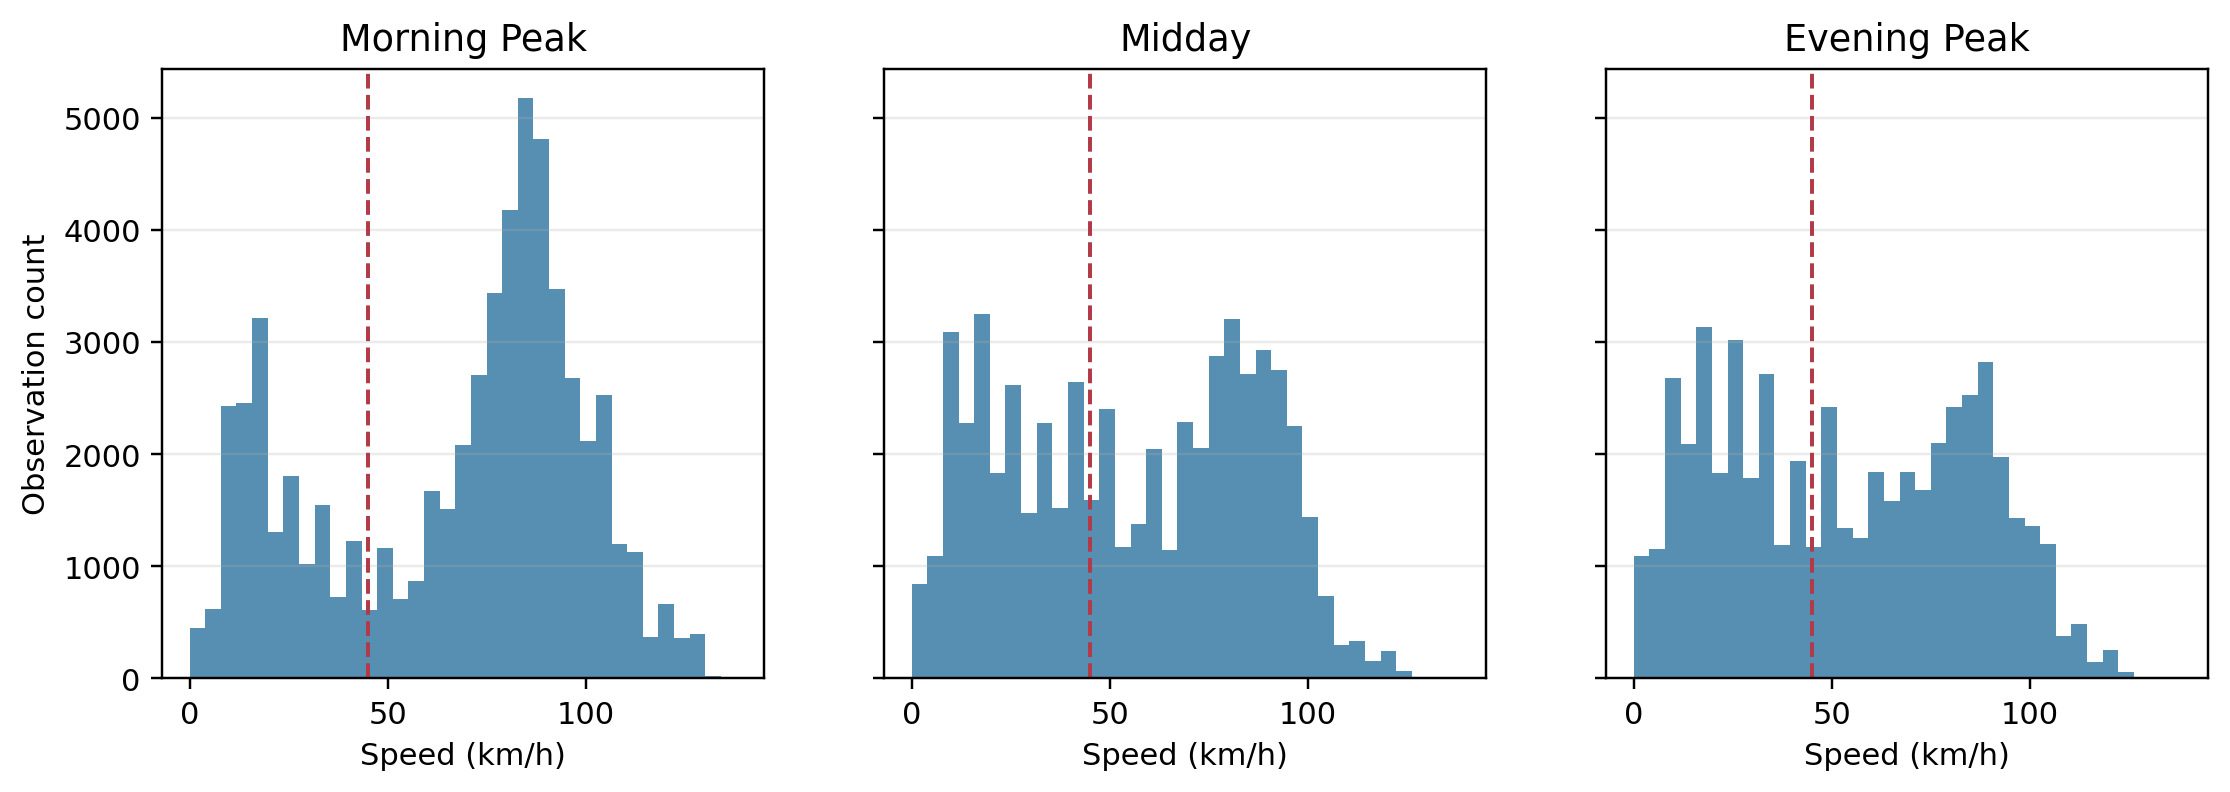

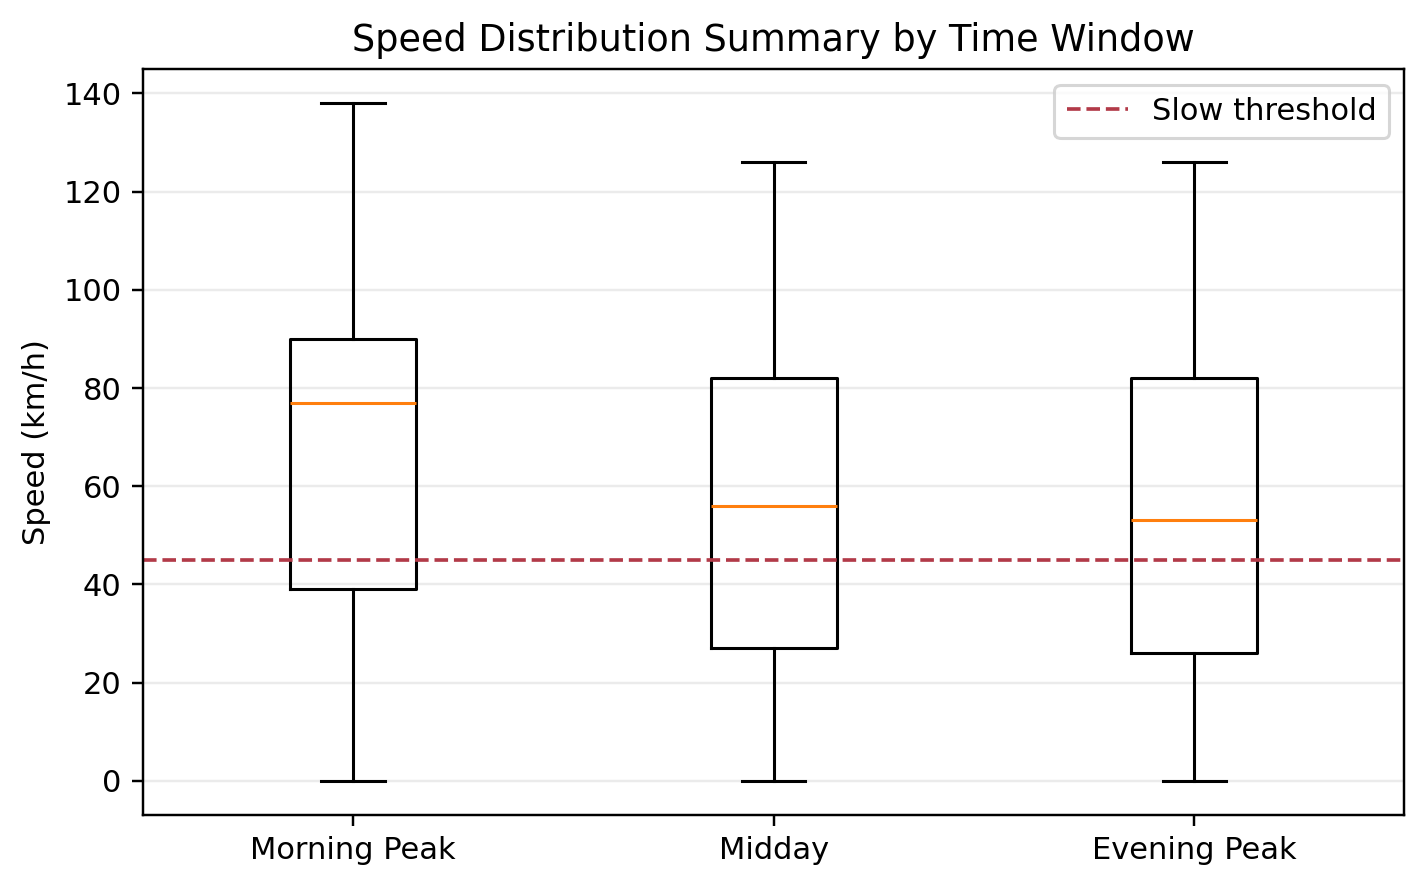

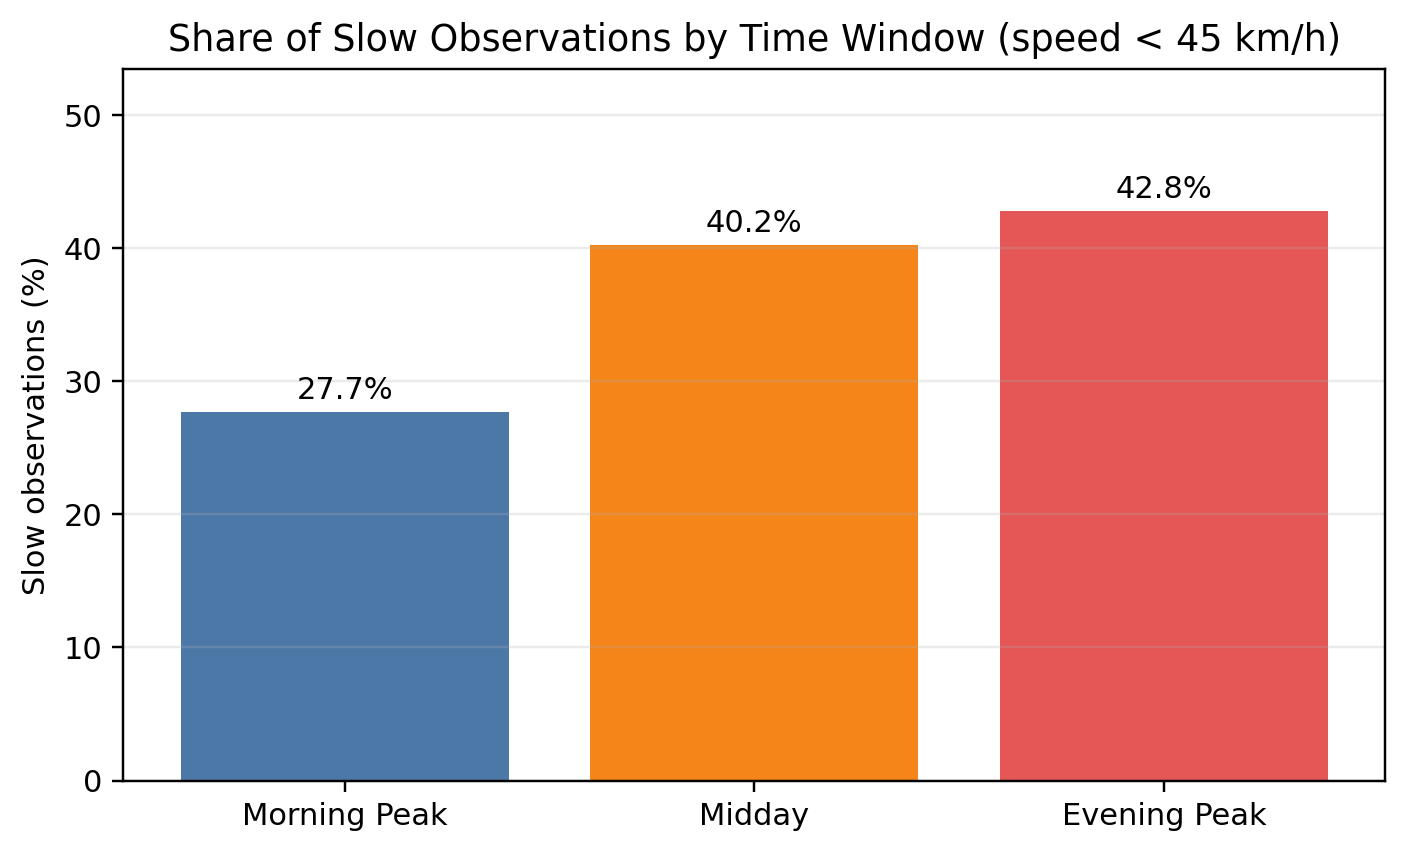

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=140, constrained_layout=True)
for ax, window in zip(axes, WINDOW_ORDER):
    speeds = df_time.loc[df_time["time_window"] == window, "speed"]
    ax.hist(speeds, bins=35, alpha=0.85)
    ax.axvline(SLOW_THRESHOLD, linestyle="--", linewidth=1)
    ax.set_title(window)
    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel("Observation count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=140)
data = [df_time.loc[df_time["time_window"] == window, "speed"] for window in WINDOW_ORDER]
ax.boxplot(data, labels=WINDOW_ORDER, showfliers=False)
ax.axhline(SLOW_THRESHOLD, linestyle="--", linewidth=1, label="Slow threshold")
ax.set_title("Speed Distribution Summary by Time Window")
ax.set_ylabel("Speed (km/h)")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
shares = time_window_summary["slow_share"] * 100
bars = ax.bar(WINDOW_ORDER, shares)
for bar, value in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.1f}%", ha="center", va="bottom")
ax.set_title(f"Share of Observations Below {SLOW_THRESHOLD} km/h by Time Window")
ax.set_ylabel("Slow observations (%)")
ax.set_ylim(0, max(shares) + 12)
plt.show()

Morning Peak is faster in this sampled corridor data. Midday and Evening Peak have lower centers and higher slow-observation shares.

## 3. Direction Summary

In [5]:
direction_summary = (
    df_route[df_route["direction"] != "Undetermined"]
    .groupby("direction")["speed"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reindex(["Eastbound", "Westbound"])
    .reset_index()
)
direction_summary

,direction,count,mean,median,std
0,Eastbound,90167,65.781284,76.0,32.180583
1,Westbound,102947,53.265166,51.0,30.335008


In [6]:
direction_time_summary = (
    df_time.groupby(["direction", "time_window"])["speed"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reset_index()
    .sort_values(["direction", "time_window"])
    .reset_index(drop=True)
)
direction_time_summary

,direction,time_window,count,mean,median,std
0,Eastbound,Midday,20048,69.931265,79.0,30.434911
1,Eastbound,Morning Peak,59192,66.712833,77.0,32.640535
2,Undetermined,Evening Peak,383,47.569191,51.0,12.805013
3,Undetermined,Midday,433,53.452656,53.0,8.369267
4,Westbound,Evening Peak,52576,53.837607,53.0,31.249051
5,Westbound,Midday,36525,47.312088,43.0,27.861949
6,Westbound,Morning Peak,1527,84.370661,85.0,10.564729


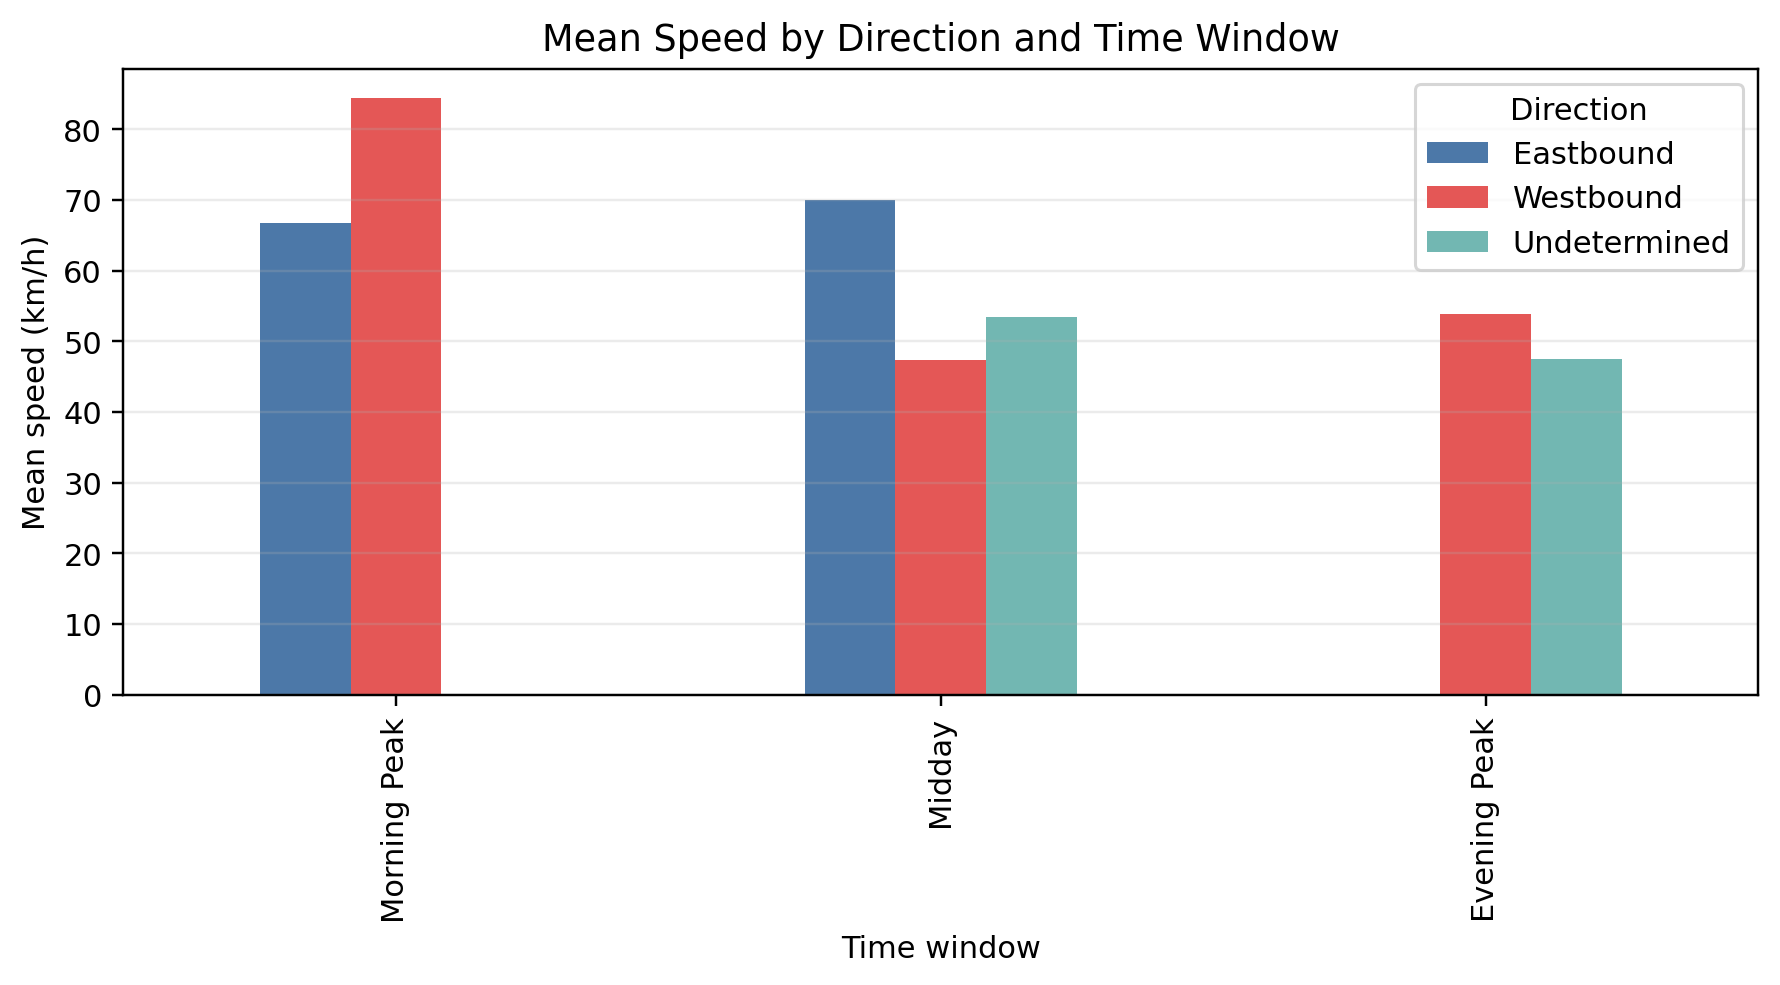

In [7]:
plot_data = direction_time_summary.pivot(index="time_window", columns="direction", values="mean").reindex(WINDOW_ORDER)
fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=140)
plot_data.plot(kind="bar", ax=ax)
ax.set_title("Mean Speed by Inferred Direction and Time Window")
ax.set_xlabel("Time window")
ax.set_ylabel("Mean speed (km/h)")
ax.legend(title="Direction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Direction matters, but the coverage is uneven. Evening Peak is mostly Westbound in this sample, so direction-time results should not be read as a balanced two-way comparison.

## 4. Hypothesis Tests

In [8]:
groups = [df_time.loc[df_time["time_window"] == window, "speed"] for window in WINDOW_ORDER]
anova_stat, anova_p = f_oneway(*groups)
kruskal_stat, kruskal_p = kruskal(*groups)

grand_mean = df_time["speed"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((df_time["speed"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

contingency = pd.crosstab(df_time["time_window"], df_time["is_slow"]).reindex(WINDOW_ORDER)
chi_stat, chi_p, chi_dof, chi_expected = chi2_contingency(contingency)
cramers_v = np.sqrt(chi_stat / (contingency.to_numpy().sum() * (min(contingency.shape) - 1)))

hypothesis_tests = pd.DataFrame([
    ["One-way ANOVA", "Mean speed is equal across Morning Peak, Midday, and Evening Peak", "F", anova_stat, "2, 170681", p_label(anova_p), 0.05, "Reject H0" if anova_p < 0.05 else "Fail to reject H0", eta_squared, "eta_squared"],
    ["Kruskal-Wallis", "Speed distributions are equal across the three time windows", "H", kruskal_stat, "2", p_label(kruskal_p), 0.05, "Reject H0" if kruskal_p < 0.05 else "Fail to reject H0", np.nan, ""],
    ["Chi-square independence", "Time window and slow/not-slow status are independent", "chi_square", chi_stat, str(chi_dof), p_label(chi_p), 0.05, "Reject H0" if chi_p < 0.05 else "Fail to reject H0", cramers_v, "cramers_v"],
], columns=["test", "null_hypothesis", "statistic_name", "statistic", "degrees_of_freedom", "p_value", "alpha", "decision", "effect_size", "effect_size_name"])
hypothesis_tests

,test,null_hypothesis,statistic_name,statistic,degrees_of_freedom,p_value,alpha,decision,effect_size,effect_size_name
0,One-way ANOVA,"Mean speed is equal across Morning Peak, Midda...",F,3162.094550,"2, 170681",< 0.001,0.05,Reject H0,0.035729,eta_squared
1,Kruskal-Wallis,Speed distributions are equal across the three...,H,6049.869189,2,< 0.001,0.05,Reject H0,NaN,
2,Chi-square independence,Time window and slow/not-slow status are indep...,chi_square,3269.446075,2,< 0.001,0.05,Reject H0,0.138401,cramers_v


In [9]:
pairs = []
for first, second in combinations(WINDOW_ORDER, 2):
    a = df_time.loc[df_time["time_window"] == first, "speed"]
    b = df_time.loc[df_time["time_window"] == second, "speed"]
    t_stat, p_value = ttest_ind(a, b, equal_var=False)
    p_adj = min(p_value * 3, 1.0)
    pairs.append([
        f"{first} vs {second}",
        "Welch t-test",
        t_stat,
        p_label(p_adj),
        a.mean() - b.mean(),
        "Reject H0" if p_adj < 0.05 else "Fail to reject H0",
    ])
pairwise_tests = pd.DataFrame(pairs, columns=["comparison", "test", "t_statistic", "p_value_bonferroni", "mean_difference_kmh", "decision_alpha_0_05"])
pairwise_tests

,comparison,test,t_statistic,p_value_bonferroni,mean_difference_kmh,decision_alpha_0_05
0,Morning Peak vs Midday,Welch t-test,64.453774,< 0.001,11.84341,Reject H0
1,Morning Peak vs Evening Peak,Welch t-test,70.821999,< 0.001,13.36463,Reject H0
2,Midday vs Evening Peak,Welch t-test,8.152242,< 0.001,1.52122,Reject H0


In [10]:
slow_contingency_table = contingency.reset_index()
slow_contingency_table

is_slow,time_window,False,True
0,Morning Peak,43911,16808
1,Midday,34083,22923
2,Evening Peak,30314,22645


In [11]:
slow_expected_counts = pd.DataFrame(chi_expected, index=WINDOW_ORDER, columns=contingency.columns).reset_index().rename(columns={"index": "time_window"})
slow_expected_counts

,time_window,False,True
0,Morning Peak,38529.407865,22189.592135
1,Midday,36173.313538,20832.686462
2,Evening Peak,33605.278597,19353.721403


The tests reject equal speed patterns across the three time windows at α = 0.05. Since the data are repeated telemetry rows from one vehicle, I treat the p-values as evidence for the sampled driving process, not as independent-driver inference.

## 5. Route Map and DBSCAN Low-Speed Zones

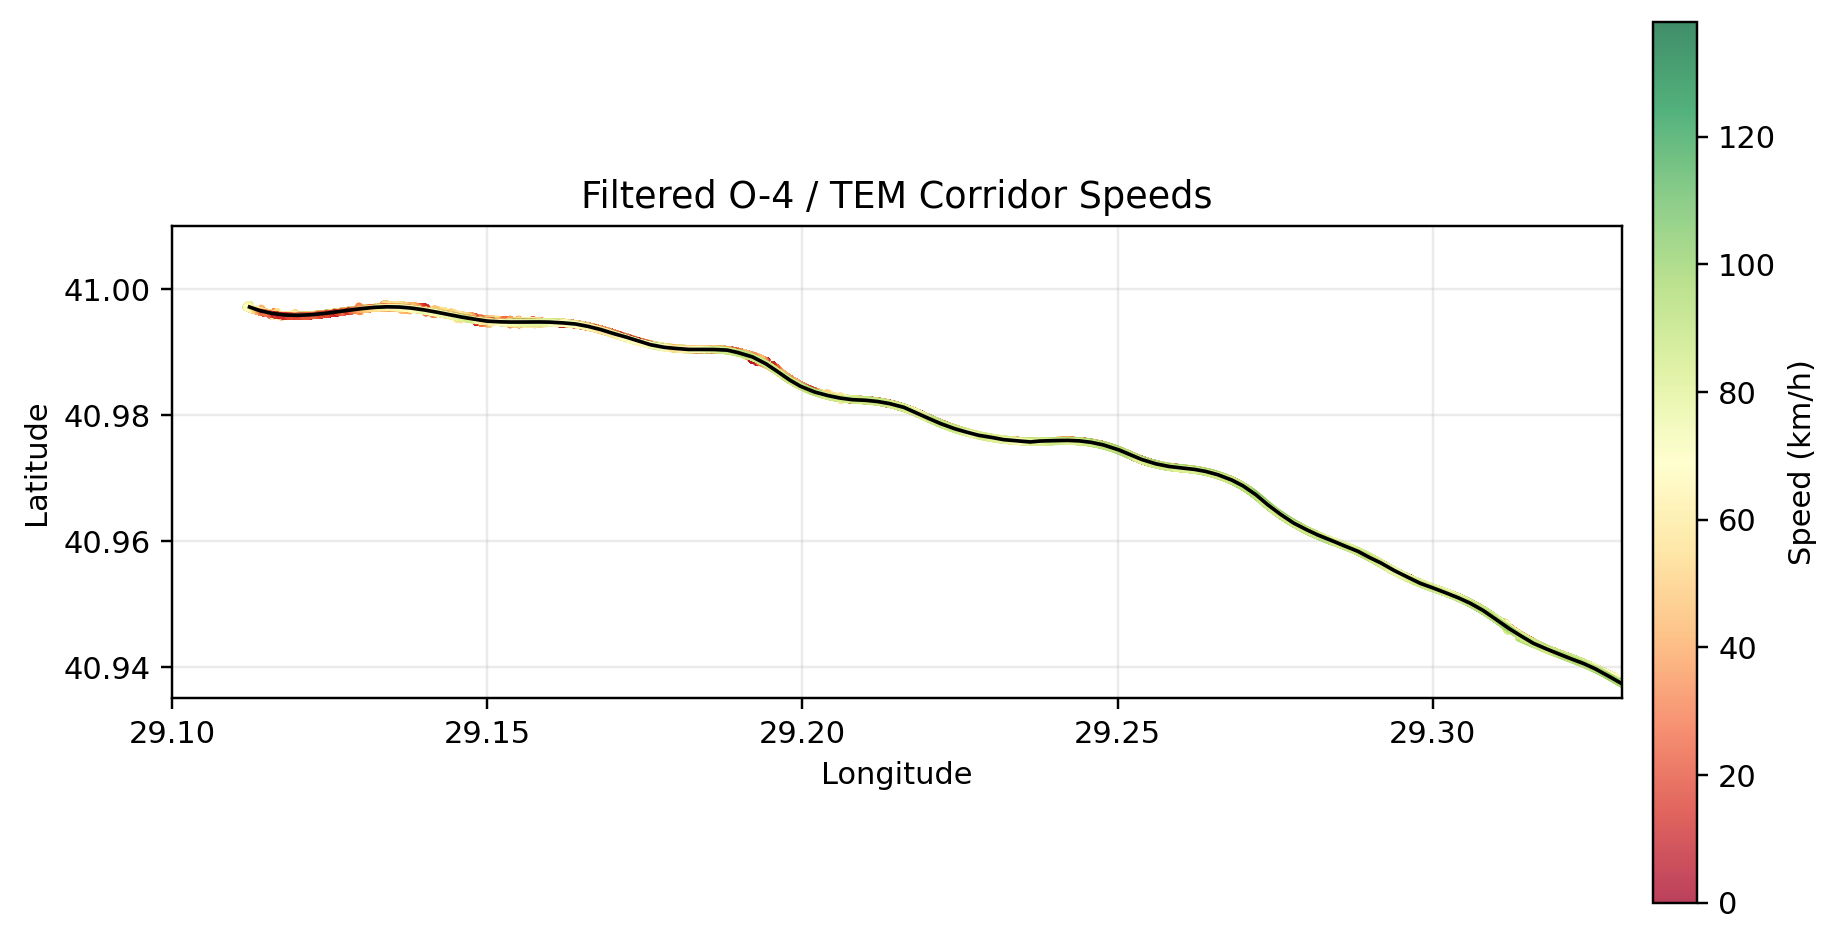

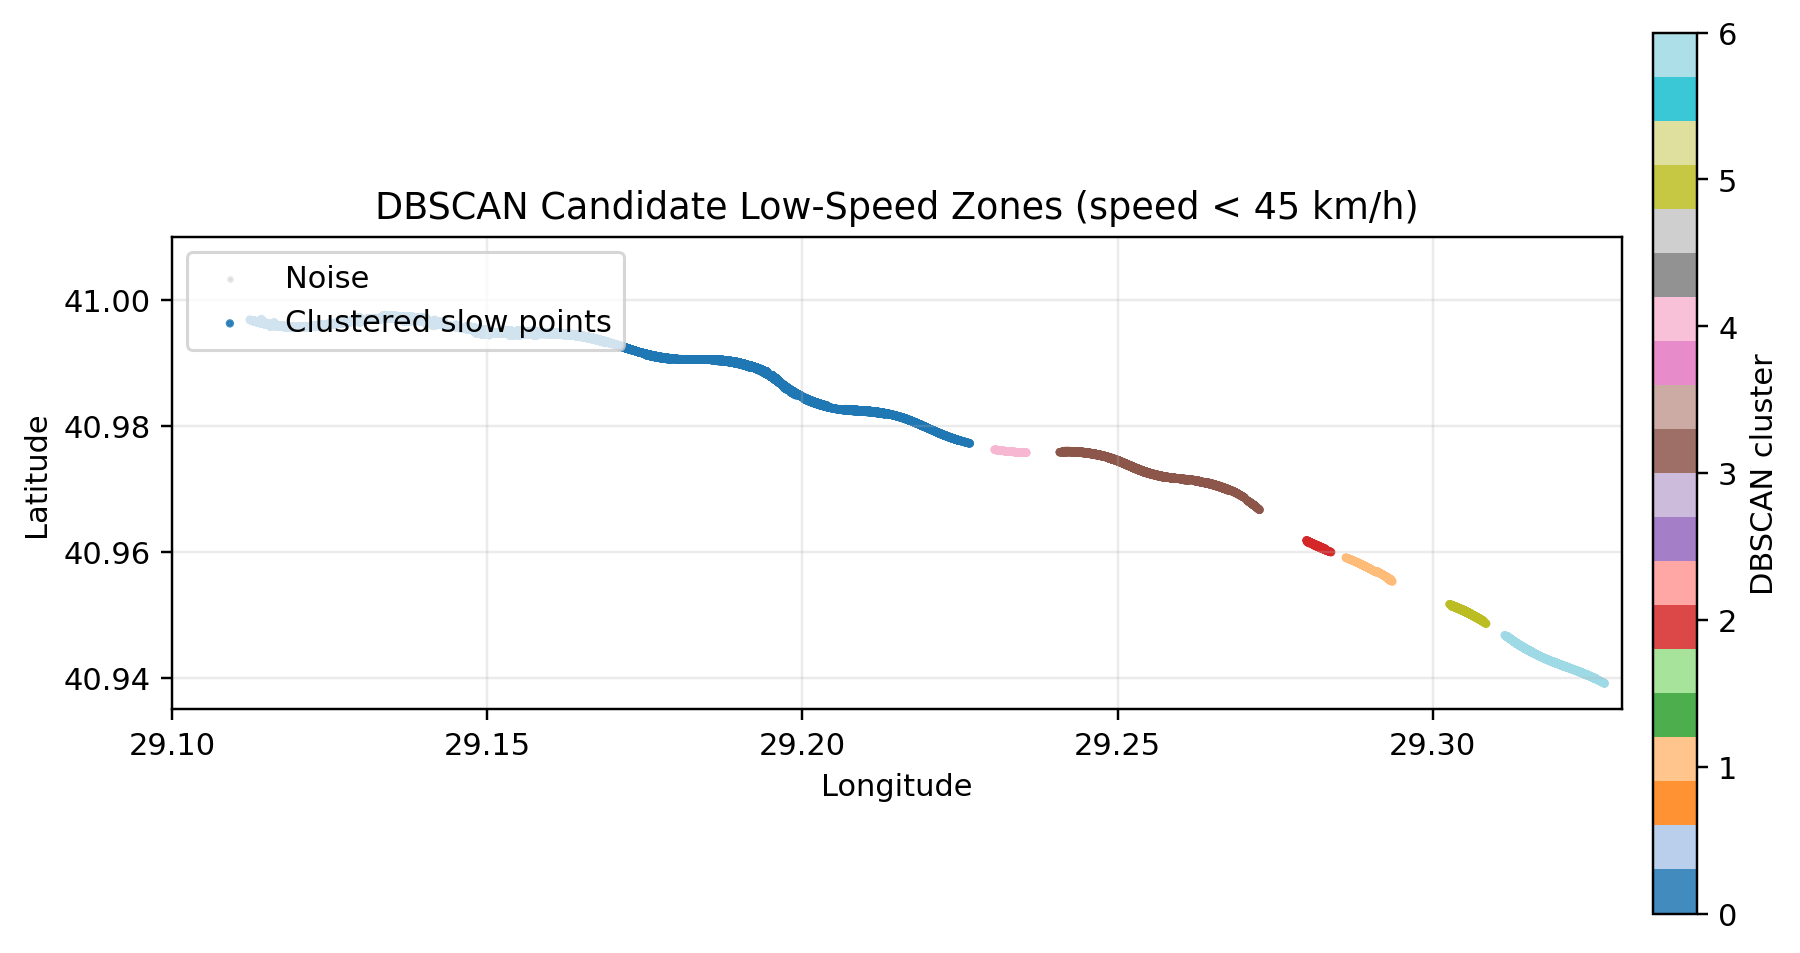

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)
scatter = ax.scatter(df_route["longitude"], df_route["latitude"], c=df_route["speed"], cmap="RdYlGn", s=2, alpha=0.85)
fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02, label="Speed (km/h)")
ax.set_title("Filtered O-4 / TEM Corridor Speeds")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(29.10, 29.33)
ax.set_ylim(40.935, 41.01)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
plt.show()

slow_points = df_time[df_time["speed"] < SLOW_THRESHOLD].copy()
eps_radians = EPS_METERS / EARTH_RADIUS_M
coords_rad = np.radians(slow_points[["latitude", "longitude"]].to_numpy())
model = DBSCAN(eps=eps_radians, min_samples=MIN_SAMPLES, metric="haversine")
slow_points["cluster"] = model.fit_predict(coords_rad)
clustered = slow_points[slow_points["cluster"] != -1]
noise = slow_points[slow_points["cluster"] == -1]

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)
ax.scatter(noise["longitude"], noise["latitude"], c="lightgray", s=2, alpha=0.5, label="Noise")
sc = ax.scatter(clustered["longitude"], clustered["latitude"], c=clustered["cluster"], cmap="tab20", s=5, alpha=0.9, label="Clustered slow points")
fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label="DBSCAN cluster")
ax.set_title(f"DBSCAN Candidate Low-Speed Zones (speed < {SLOW_THRESHOLD} km/h)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(29.10, 29.33)
ax.set_ylim(40.935, 41.01)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
plt.show()

In [13]:
dbscan_cluster_summary = (
    slow_points[slow_points["cluster"] != -1]
    .groupby("cluster")
    .agg(
        point_count=("speed", "count"),
        mean_speed=("speed", "mean"),
        median_speed=("speed", "median"),
        min_speed=("speed", "min"),
        route_position_km=("route_position_km", "mean"),
        route_position_min_km=("route_position_km", "min"),
        route_position_max_km=("route_position_km", "max"),
        dominant_time_window=("time_window", dominant_value),
        dominant_direction=("direction", dominant_value),
        center_lat_approx=("latitude", "mean"),
        center_lon_approx=("longitude", "mean"),
    )
    .reset_index()
)
dbscan_cluster_summary["route_span_km"] = dbscan_cluster_summary["route_position_max_km"] - dbscan_cluster_summary["route_position_min_km"]
dbscan_cluster_summary["center_lat_approx"] = dbscan_cluster_summary["center_lat_approx"].round(3)
dbscan_cluster_summary["center_lon_approx"] = dbscan_cluster_summary["center_lon_approx"].round(3)
dbscan_cluster_summary = dbscan_cluster_summary.sort_values("point_count", ascending=False).reset_index(drop=True)
dbscan_cluster_summary

,cluster,point_count,mean_speed,median_speed,min_speed,route_position_km,route_position_min_km,route_position_max_km,dominant_time_window,dominant_direction,route_span_km,center_lat_approx,center_lon_approx
0,0,54928,21.700754,19.0,0,4.080994,0.015435,10.125125,Midday,Westbound,10.109690,40.993,29.160
1,3,3833,28.574485,29.0,0,12.644141,11.348561,14.275641,Midday,Westbound,2.927080,40.973,29.255
2,6,2285,24.355799,24.0,0,18.992633,18.241335,19.831888,Evening Peak,Westbound,1.590552,40.943,29.319
3,5,473,34.871036,35.0,16,17.607483,17.327216,17.922898,Evening Peak,Westbound,0.595682,40.950,29.305
4,1,419,24.081146,23.0,5,16.108848,15.712896,16.466350,Morning Peak,Eastbound,0.753454,40.957,29.290
5,2,254,38.602362,40.0,31,15.286074,15.107081,15.494370,Morning Peak,Westbound,0.387289,40.961,29.282
6,4,175,31.125714,35.0,11,10.675278,10.476384,10.898145,Morning Peak,Eastbound,0.421760,40.976,29.233


DBSCAN finds seven low-speed zones under the 45 km/h threshold. Cluster 0 is much larger than the others and spans a long route interval, so it behaves like a continuous slow region instead of a tiny isolated hotspot.

## 6. Threshold Sensitivity

In [14]:
def run_dbscan_for_threshold(df, threshold):
    points = df[df["speed"] < threshold].copy()
    coords = np.radians(points[["latitude", "longitude"]].to_numpy())
    model = DBSCAN(eps=EPS_METERS / EARTH_RADIUS_M, min_samples=MIN_SAMPLES, metric="haversine")
    points["cluster"] = model.fit_predict(coords)
    clustered = points[points["cluster"] != -1]
    largest = int(clustered["cluster"].value_counts().max()) if len(clustered) else 0
    return {
        "threshold_kmh": threshold,
        "slow_points": len(points),
        "clusters": clustered["cluster"].nunique(),
        "noise_points": int((points["cluster"] == -1).sum()),
        "largest_cluster_points": largest,
    }

threshold_sensitivity = pd.DataFrame([run_dbscan_for_threshold(df_time, t) for t in [40, 45, 50]])
threshold_sensitivity

,threshold_kmh,slow_points,clusters,noise_points,largest_cluster_points
0,40,56570,7,0,50251
1,45,62376,7,9,54928
2,50,68063,7,37,59314


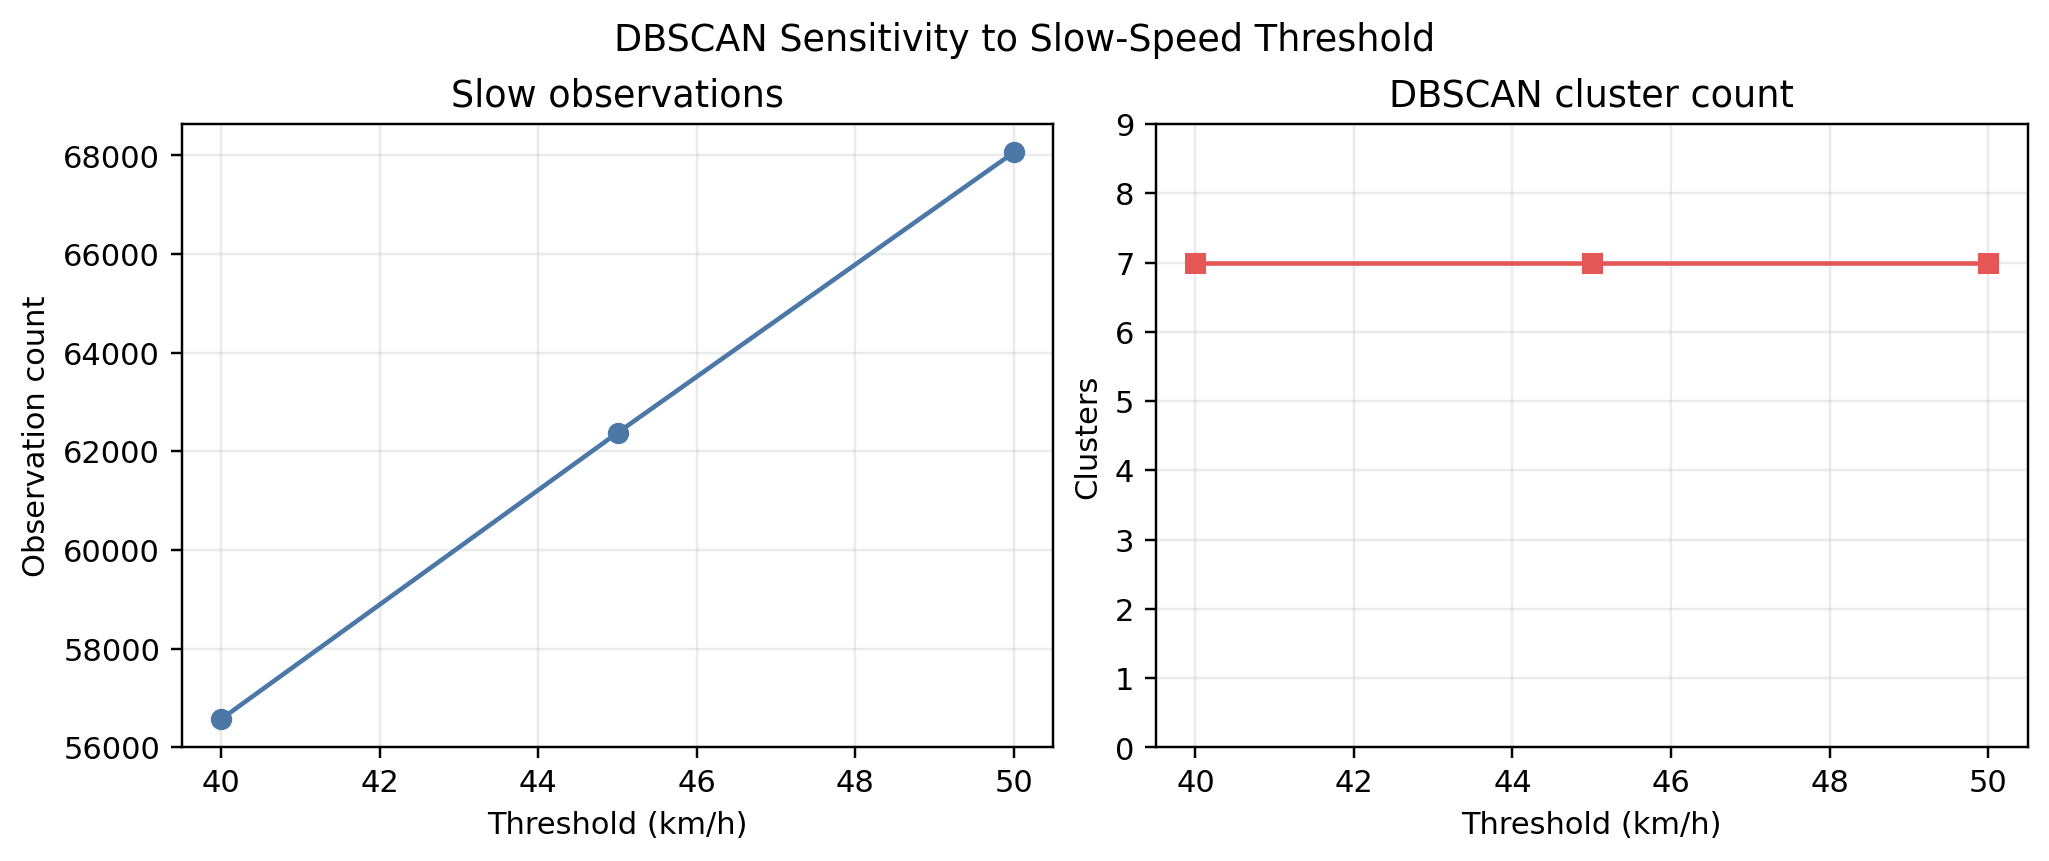

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), dpi=140, constrained_layout=True)
axes[0].plot(threshold_sensitivity["threshold_kmh"], threshold_sensitivity["slow_points"], marker="o")
axes[0].set_title("Slow observations")
axes[0].set_xlabel("Threshold (km/h)")
axes[0].set_ylabel("Observation count")
axes[0].grid(True, alpha=0.25)

axes[1].plot(threshold_sensitivity["threshold_kmh"], threshold_sensitivity["clusters"], marker="s")
axes[1].set_title("DBSCAN cluster count")
axes[1].set_xlabel("Threshold (km/h)")
axes[1].set_ylabel("Clusters")
axes[1].set_ylim(0, max(threshold_sensitivity["clusters"]) + 2)
axes[1].grid(True, alpha=0.25)
fig.suptitle("DBSCAN Sensitivity to Slow-Speed Threshold")
plt.show()

The number of DBSCAN clusters stays at seven for 40, 45, and 50 km/h. The threshold changes how many points are called slow, but it does not change the main cluster count.